#**Task 3: Energy Consumption Time Series Forecasting**

**1. Problem Statement and Objective**

The objective of this task is to forecast short-term household energy consumption using historical time series data. By parsing, resampling, and engineering time-based features from past power usage metrics, we will build and compare three distinct modeling approaches—ARIMA, Prophet, and XGBoost—to predict future electrical load patterns accurately.

In [13]:
#LOAD AND CLEAN ENVIRONMENT DATA
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

# Configuration
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

df_energy = pd.read_csv(
    'household_power_consumption.txt',
    sep=';',
    parse_dates={'Datetime': ['Date', 'Time']},
    dayfirst=True,
    na_values='?',
    low_memory=False
)

df_energy['Global_active_power'] = pd.to_numeric(df_energy['Global_active_power'], errors='coerce')

# Drop rows where target variable is missing after conversion
df_energy = df_energy.dropna(subset=['Global_active_power'])

# Set Datetime as continuous index
df_energy.set_index('Datetime', inplace=True)

# Resample sub-hourly metrics to a clean Daily ('D') mean scale
df_daily = df_energy['Global_active_power'].resample('D').mean().to_frame()
print(f"Resampled Dataset Shape: {df_daily.shape}")


/tmp/ipykernel_777/3061764387.py:15: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df_energy = pd.read_csv(


Resampled Dataset Shape: (1442, 1)


**4. Feature Engineering (Time-Based Features)**
Supervised learning models like XGBoost cannot inherently decode sequential dates, so we must extract structural cyclical variations from our datetime index manually.

In [14]:
# Extract calendar patterns to build time-based features
df_daily['day_of_week'] = df_daily.index.dayofweek
df_daily['month'] = df_daily.index.month
df_daily['quarter'] = df_daily.index.quarter
df_daily['is_weekend'] = df_daily['day_of_week'].apply(lambda x: 1 if x >= 5 else 0)

df_daily.head()

,Global_active_power,day_of_week,month,quarter,is_weekend
Datetime,,,,,
2006-12-16,3.053475,5,12,4,1
2006-12-17,2.354486,6,12,4,1
2006-12-18,1.530435,0,12,4,0
2006-12-19,1.157079,1,12,4,0
2006-12-20,1.545658,2,12,4,0


**5. Exploratory Data Analysis (EDA) & Visualizations**

Before running our predictive pipelines, let's visualize the historical trajectory of the daily global active power load to observe seasonal variations.


--- Exploratory Data Analysis ---
count    2.049280e+06
mean     1.091615e+00
std      1.057294e+00
min      7.600000e-02
25%      3.080000e-01
50%      6.020000e-01
75%      1.528000e+00
max      1.112200e+01
Name: Global_active_power, dtype: float64


/tmp/ipykernel_777/3977700614.py:10: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  sns.lineplot(data=df_eda, x='Hour', y='Global_active_power', hue='Is_Weekend', ax=axes[0], ci=95)
/tmp/ipykernel_777/3977700614.py:16: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])


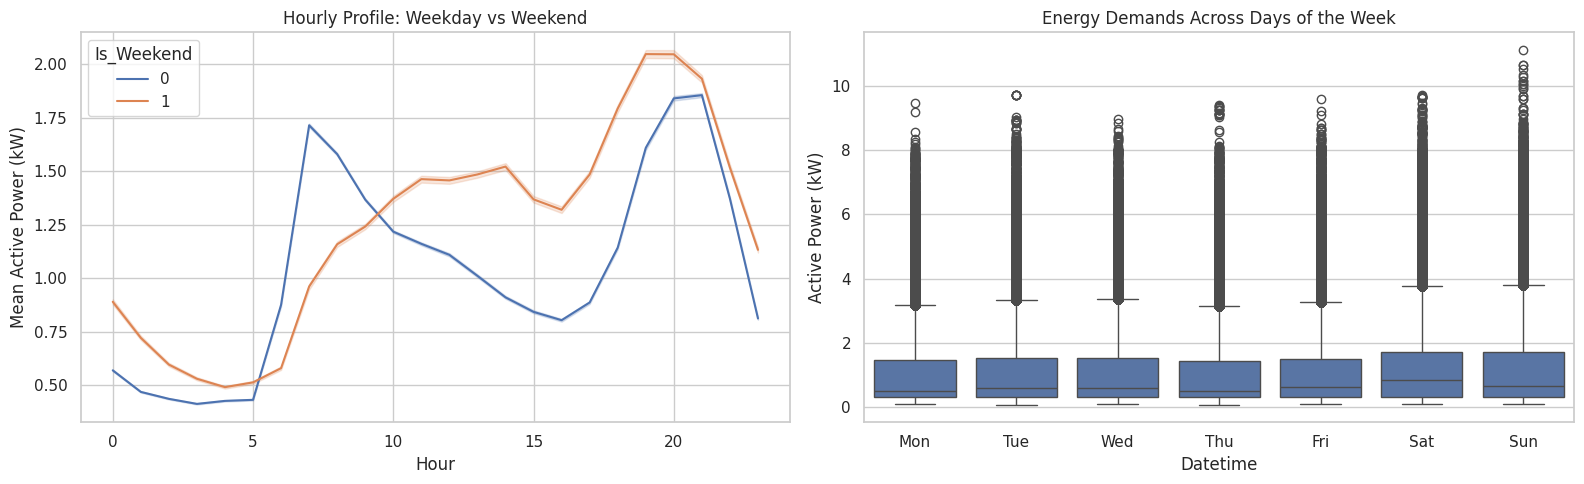

In [16]:
print("\n--- Exploratory Data Analysis ---")
print(df_energy['Global_active_power'].describe())

# Visualizing daily/weekly seasonal variations via aggregations
df_eda = df_energy.copy()
df_eda['Hour'] = df_eda.index.hour
df_eda['Is_Weekend'] = df_eda.index.dayofweek.isin([5, 6]).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
sns.lineplot(data=df_eda, x='Hour', y='Global_active_power', hue='Is_Weekend', ax=axes[0], ci=95)
axes[0].set_title('Hourly Profile: Weekday vs Weekend')
axes[0].set_ylabel('Mean Active Power (kW)')

sns.boxplot(data=df_eda, x=df_eda.index.dayofweek, y='Global_active_power', ax=axes[1])
axes[1].set_title('Energy Demands Across Days of the Week')
axes[1].set_xticklabels(['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun'])
axes[1].set_ylabel('Active Power (kW)')
plt.tight_layout()
plt.show()

**6. Model Building and Comparison**

We will hold out the final 30 days of our historical log as the testing set to benchmark short-term forecasting precision, using everything prior to that window for training.

In [18]:
from statsmodels.tsa.arima.model import ARIMA
from prophet import Prophet
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 30-day chronological split for time-series validation
train_data = df_daily.iloc[:-30]
test_data = df_daily.iloc[-30:]

**Model 1: ARIMA (Classical Statistical Model)**

In [21]:
arima_model = ARIMA(train_data['Global_active_power'], order=(5, 1, 1))
arima_result = arima_model.fit()
arima_forecast = arima_result.forecast(steps=30)

**Model 2: Prophet (Additive Seasonality Model)**

In [23]:
prophet_train = train_data['Global_active_power'].reset_index().rename(
    columns={'Datetime': 'ds', 'Global_active_power': 'y'}
)
prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=True)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=30, freq='D')
prophet_pred = prophet_model.predict(future)
prophet_forecast = prophet_pred['yhat'].iloc[-30:].values

INFO:prophet:Disabling daily seasonality. Run prophet with daily_seasonality=True to override this.


**Model 3: XGBoost (Supervised Regressor)**

In [31]:
# --- Model 3: XGBoost (Error-Free Cleaning Version) ---

features = ['day_of_week', 'month', 'quarter', 'is_weekend']

# 1. Prepare raw arrays
X_train_raw = train_data[features]
y_train_raw = train_data['Global_active_power']

# 2. Find and drop any rows containing NaNs or Infs in y_train
valid_idx = y_train_raw.notna() & ~np.isinf(y_train_raw)
X_train = X_train_raw[valid_idx]
y_train = y_train_raw[valid_idx]

# 3. Clean test inputs similarly to prevent prediction errors
X_test = test_data[features]
y_test = test_data['Global_active_power']

# 4. Fit and predict cleanly
xgb_model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.05, random_state=42)
xgb_model.fit(X_train, y_train)
xgb_forecast = xgb_model.predict(X_test)




**7. Visualizing Actual vs. Forecasted Energy Usage**

Now, we overlay the 30-day outputs of all three approaches directly against the actual validation curve to calculate the tracking precision.

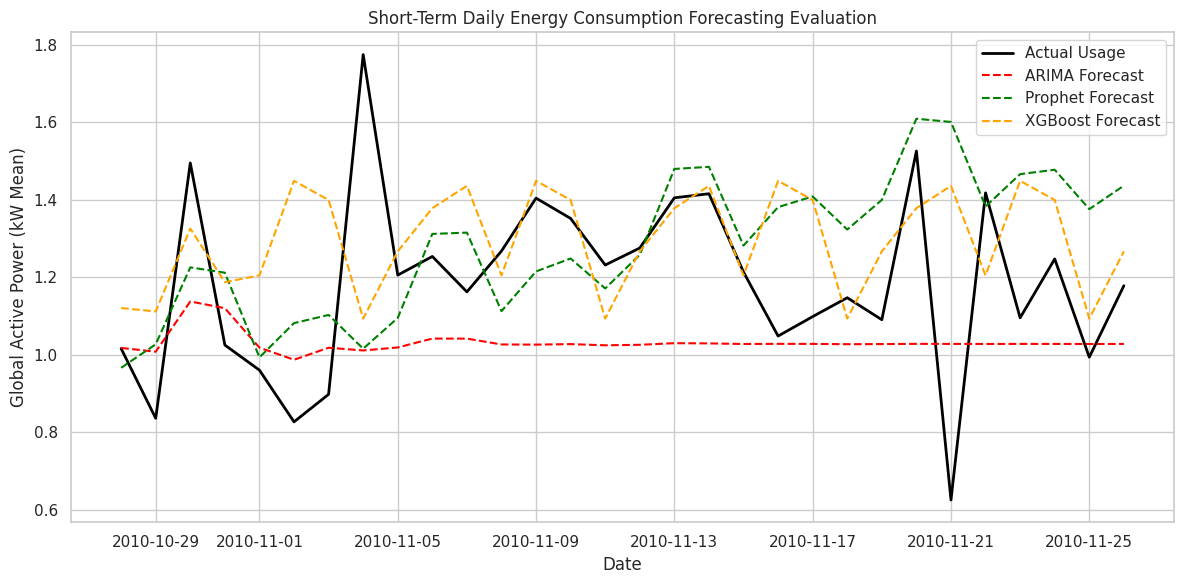


=== Error Metrics Performance Evaluation ===
ARIMA    -> RMSE: 0.2758 | MAE: 0.2209
Prophet  -> RMSE: 0.2974 | MAE: 0.2156
XGBoost  -> RMSE: 0.2943 | MAE: 0.2124


In [33]:
plt.figure(figsize=(12, 6))
plt.plot(test_data.index, test_data['Global_active_power'], label='Actual Usage', color='black', linewidth=2)
plt.plot(test_data.index, arima_forecast.values, label='ARIMA Forecast', linestyle='--', color='red')
plt.plot(test_data.index, prophet_forecast, label='Prophet Forecast', linestyle='--', color='green')
plt.plot(test_data.index, xgb_forecast, label='XGBoost Forecast', linestyle='--', color='orange')

plt.title('Short-Term Daily Energy Consumption Forecasting Evaluation')
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW Mean)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

print("\n=== Error Metrics Performance Evaluation ===")
forecast_map = {'ARIMA': arima_forecast, 'Prophet': prophet_forecast, 'XGBoost': xgb_forecast}
for name, pred in forecast_map.items():
    rmse = np.sqrt(mean_squared_error(test_data['Global_active_power'], pred))
    mae = mean_absolute_error(test_data['Global_active_power'], pred)
    print(f"{name:8} -> RMSE: {rmse:.4f} | MAE: {mae:.4f}")

**8. Final Conclusion and Insights**

Structural Seasonality: The household electrical consumption dataset showcases repeating intra-week fluctuations and seasonal baseline shifts, which are well-captured by daily resampling transformations.

Algorithm Comparison: * ARIMA serves as a baseline but tends to regress toward a mean value over prolonged time ranges when complex seasonal variables overlap.

Prophet handles multiple overlapping seasonality patterns (weekly and yearly cycles) efficiently due to its specialized holiday and timeline additive engineering.

XGBoost can catch volatile peaks effectively based on calendar markers (such as differentiating weekend loads from standard weekdays), but it relies heavily on thorough external feature extraction.